# Description:- 

Retailers face significant losses due to inaccurate demand estimates, causing stockouts or overstock situations. Traditional forecasting models struggle with dynamic market 
conditions.

# GOAL:-

To develop a machine learning model that predicts future inventory demand using historical sales data, seasonality, and consumer 
trends, improving stock management and profitability

In [1]:
## 1. Importing libraries.
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 2. Data Loading 
df = pd.read_csv('data/train.csv')
print(df)

              date  store  item  sales
0       2013-01-01      1     1     13
1       2013-01-02      1     1     11
2       2013-01-03      1     1     14
3       2013-01-04      1     1     13
4       2013-01-05      1     1     10
...            ...    ...   ...    ...
912995  2017-12-27     10    50     63
912996  2017-12-28     10    50     59
912997  2017-12-29     10    50     74
912998  2017-12-30     10    50     62
912999  2017-12-31     10    50     82

[913000 rows x 4 columns]


In [3]:
# 3 Exploratory Data Analysis
print(f"Shape of the dataset: {df.shape}")
print(df.info())

print("Column Names:")
print(df.columns)
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
# Statistical summary
print("Statistical Summary:")
print(df.describe())
# Missing values 
print("\nMissing Values:")
print(df.isnull().sum())
# Cardinality 
cardinality = df.nunique()

print("Unique values per column:")
print(cardinality)

Shape of the dataset: (913000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB
None
Column Names:
Index(['date', 'store', 'item', 'sales'], dtype='str')
Memory  : 75.8 MB
Duplicate rows: 0
Statistical Summary:
               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max        10.000000      50.000000     231.000000

Missing Value

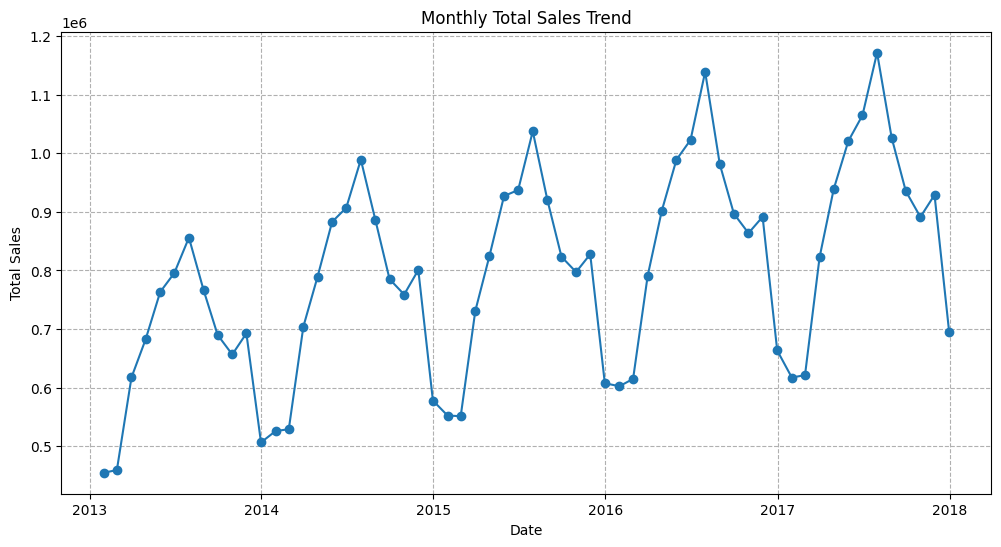

In [4]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])


# Aggregate monthly sales for visualization
monthly_sales = df.resample('ME', on='date')['sales'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 6))
plt.grid(linestyle="--")
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Monthly Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [5]:
# 4 TIME FEATURES (FEATURE ENGINEERING)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["quarter"] = df["date"].dt.quarter

df["time_index"] = (
    df["date"] - df["date"].min()
).dt.days
df
print("\nColumn Names:")
print(df.columns)
print(df.info())
df.dtypes


Column Names:
Index(['date', 'store', 'item', 'sales', 'year', 'month', 'day', 'day_of_week',
       'is_weekend', 'quarter', 'time_index'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         913000 non-null  datetime64[us]
 1   store        913000 non-null  int64         
 2   item         913000 non-null  int64         
 3   sales        913000 non-null  int64         
 4   year         913000 non-null  int32         
 5   month        913000 non-null  int32         
 6   day          913000 non-null  int32         
 7   day_of_week  913000 non-null  int32         
 8   is_weekend   913000 non-null  int64         
 9   quarter      913000 non-null  int32         
 10  time_index   913000 non-null  int64         
dtypes: datetime64[us](1), int32(5), int64(5)
memory usage: 59.2 MB
None


date           datetime64[us]
store                   int64
item                    int64
sales                   int64
year                    int32
month                   int32
day                     int32
day_of_week             int32
is_weekend              int64
quarter                 int32
time_index              int64
dtype: object

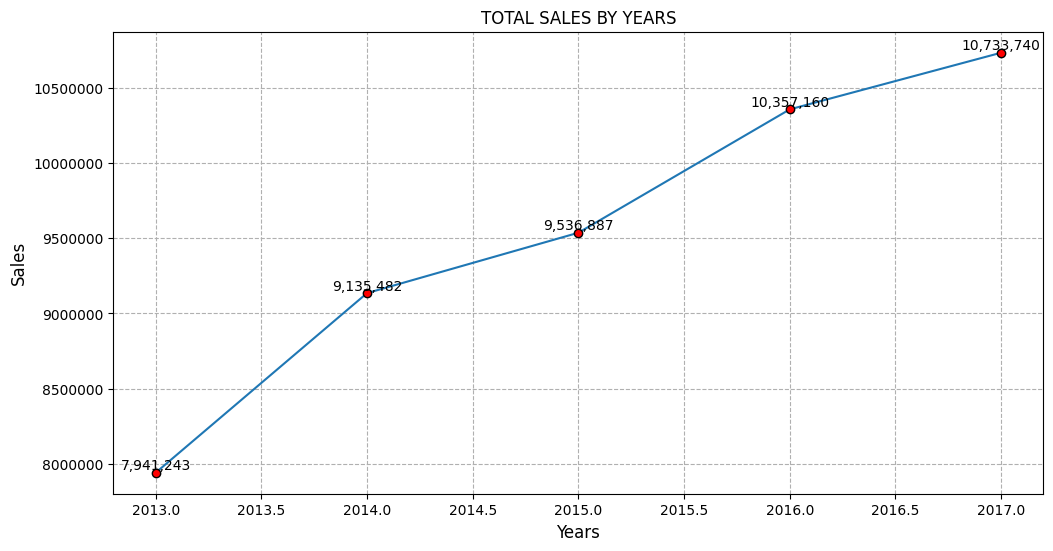

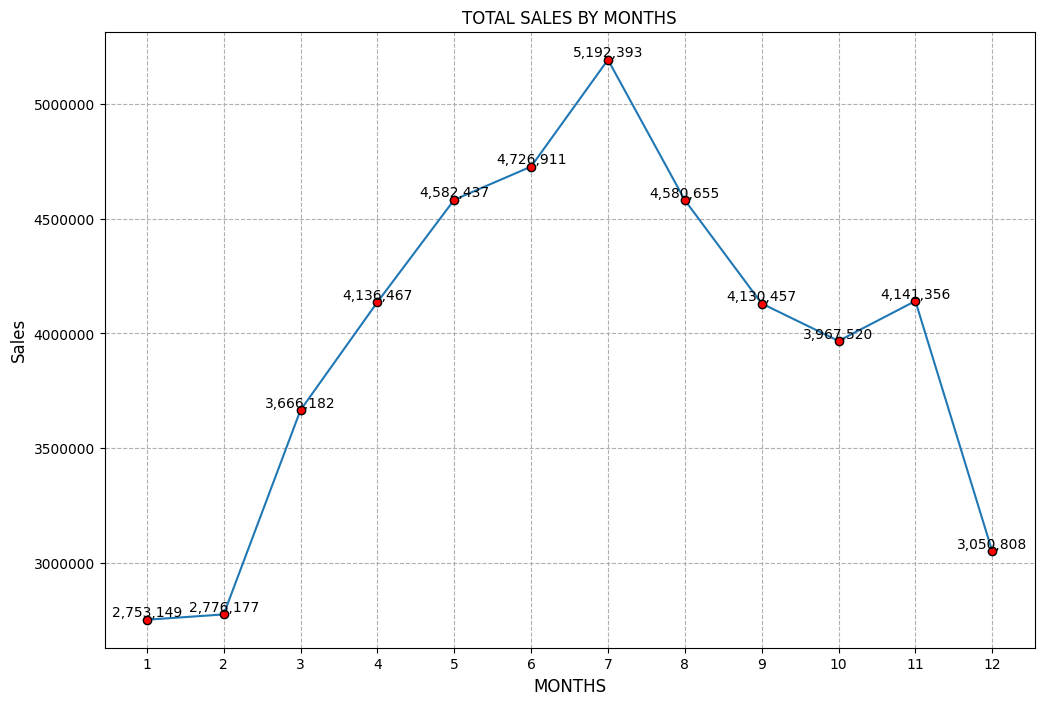

In [6]:
sales_by_year = df.groupby('year')['sales'].sum()

plt.figure(figsize=(12,6))
plt.grid(linestyle='--')
plt.plot(sales_by_year.index , sales_by_year.values , marker='o', markerfacecolor='red', markeredgecolor='black')
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=10)
plt.ticklabel_format(style='plain', axis='y')  # show full numbers on y axis
plt.title('TOTAL SALES BY YEARS')
plt.xlabel('Years',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.show()
sales_by_month = df.groupby('month')['sales'].sum()

# Plot sales by month
plt.figure(figsize=(12,8))
plt.grid(linestyle='--')
plt.plot(sales_by_month.index , sales_by_month.values , marker='o', markerfacecolor='red', markeredgecolor='black')
for x, y in zip(sales_by_month.index, sales_by_month.values):
    plt.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=10)
plt.ticklabel_format(style='plain', axis='y')  # show full numbers of y axix
plt.title('TOTAL SALES BY MONTHS')
plt.xlabel('MONTHS',fontsize=12)
plt.ylabel('Sales',fontsize=12)
plt.xticks(range(1, 13)) 
plt.show()

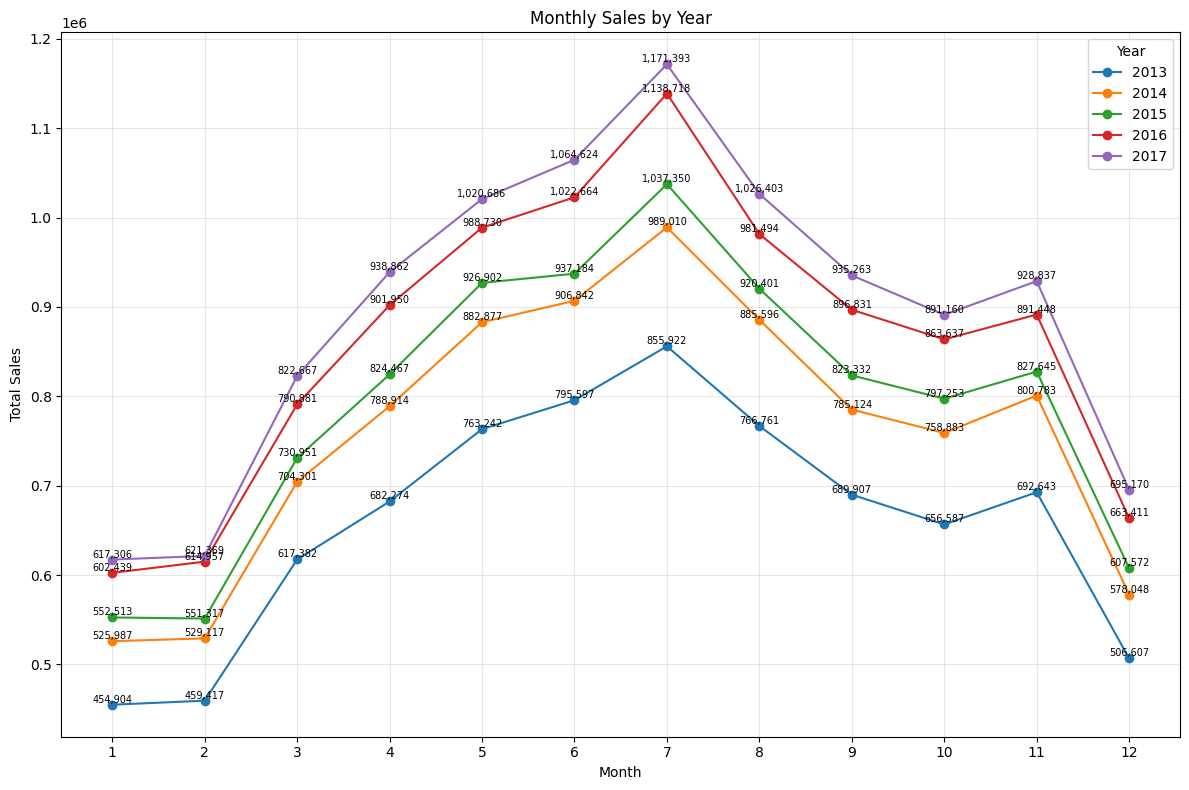

In [7]:
# Aggregate sales by year and month
monthly_year_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()

# Pivot for plotting
pivot_table = monthly_year_sales.pivot(index='month', columns='year', values='sales')

pivot_with_totals = pivot_table.copy()

# Add TOTAL column (row-wise sum)
pivot_with_totals['Total'] = pivot_with_totals.sum(axis=1)

# Add TOTAL row (column-wise sum)
pivot_with_totals.loc['Total'] = pivot_with_totals.sum()


# Plot
plt.figure(figsize=(12, 8))
plt.grid(alpha=0.3)

# Plot each year
for year in pivot_table.columns:
    plt.plot(
        pivot_table.index,
        pivot_table[year],
        marker='o',
        label=year
    )

# Add value labels 
for year in pivot_table.columns:
    for month in pivot_table.index:
        value = pivot_table.loc[month, year]
        
        if pd.notna(value):
            plt.text(
                month,
                value,
                f"{int(value):,}",
                fontsize=7,
                ha='center',
                va='bottom'
            )

# Formatting
plt.title("Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Year")
plt.xticks(range(1, 13))  # ensures months 1–12 show properly

plt.tight_layout()
plt.show()

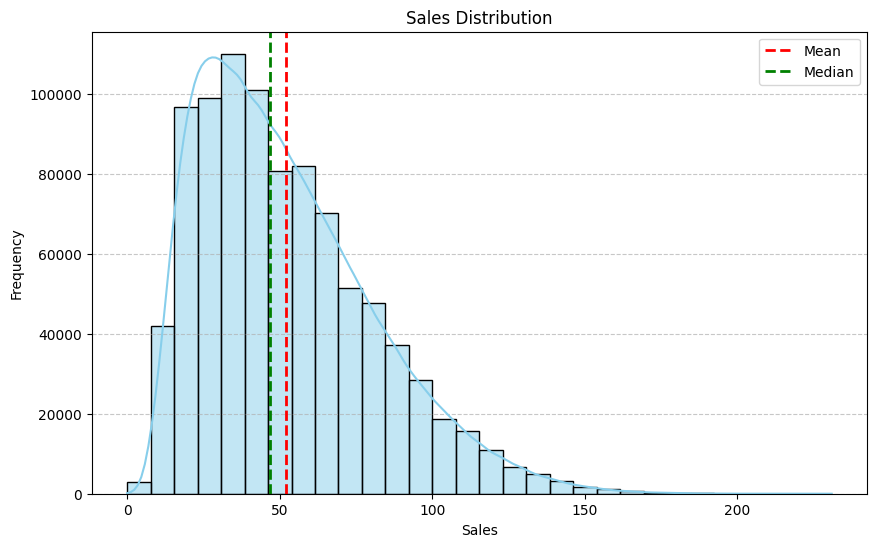

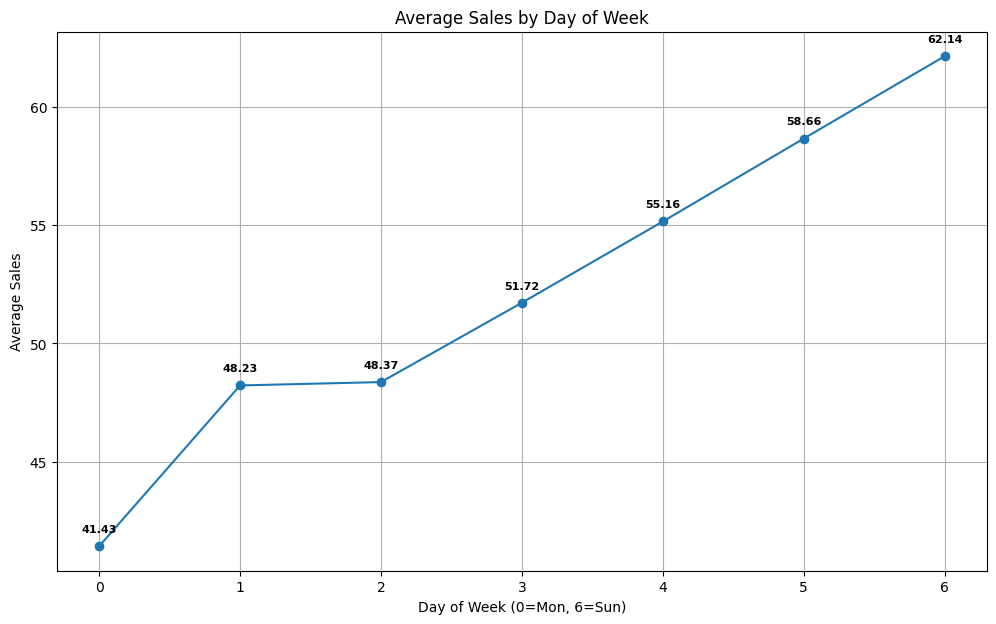

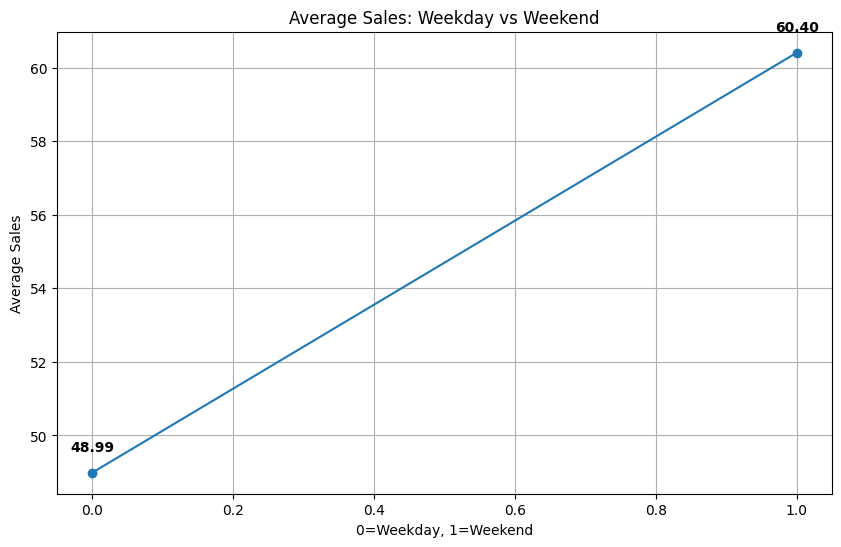

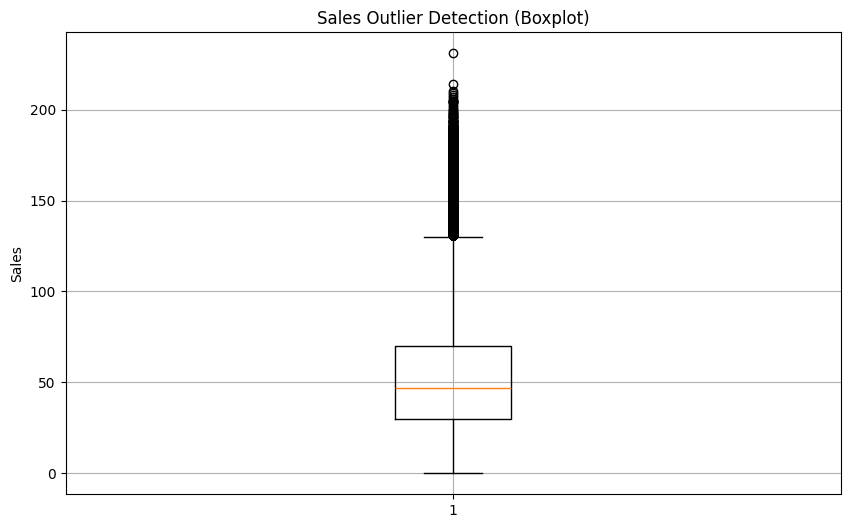

In [8]:
# Display pivot table
#pivot_table
pivot_with_totals
# Sales Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['sales'], bins=30, kde=True, color='skyblue', edgecolor='black')
# Mean & Median lines
plt.axvline(df['sales'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['sales'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Sales by Day of Week
sales_by_dow = df.groupby('day_of_week')['sales'].mean()
plt.figure(figsize=(12, 7))
plt.grid()
plt.plot(sales_by_dow.index, sales_by_dow.values,marker="o")
for x, y in zip(sales_by_dow.index, sales_by_dow.values):
    plt.text(x, y + 0.5, f'{y:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Average Sales")
plt.show()

# Weekend vs Weekday Sales
weekend_sales = df.groupby('is_weekend')['sales'].mean()

plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(weekend_sales.index, weekend_sales.values,marker="o")
for x, y in zip(weekend_sales.index, weekend_sales.values):
    plt.text(x, y + 0.5, f'{y:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Average Sales: Weekday vs Weekend")
plt.xlabel("0=Weekday, 1=Weekend")
plt.ylabel("Average Sales")
plt.show()

# Outlier Detection (Boxplot)
plt.figure(figsize=(10, 6))
plt.grid()
plt.boxplot(df['sales'])
plt.title("Sales Outlier Detection (Boxplot)")
plt.ylabel("Sales")
plt.show()

In [9]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["sales"] < lower_bound) |
    (df["sales"] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers


Number of outliers: 11967


,date,store,item,sales,year,month,day,day_of_week,is_weekend,quarter,time_index
21330,2016-05-29,2,2,139,2016,5,29,6,1,2,1244
21344,2016-06-12,2,2,131,2016,6,12,6,1,2,1258
21365,2016-07-03,2,2,138,2016,7,3,6,1,3,1279
21372,2016-07-10,2,2,134,2016,7,10,6,1,3,1286
21399,2016-08-06,2,2,136,2016,8,6,5,1,3,1313
...,...,...,...,...,...,...,...,...,...,...,...
912796,2017-06-11,10,50,137,2017,6,11,6,1,2,1622
912803,2017-06-18,10,50,150,2017,6,18,6,1,2,1629
912824,2017-07-09,10,50,135,2017,7,9,6,1,3,1650
912831,2017-07-16,10,50,143,2017,7,16,6,1,3,1657


30.0 70.0 40.0 -30.0 130.0


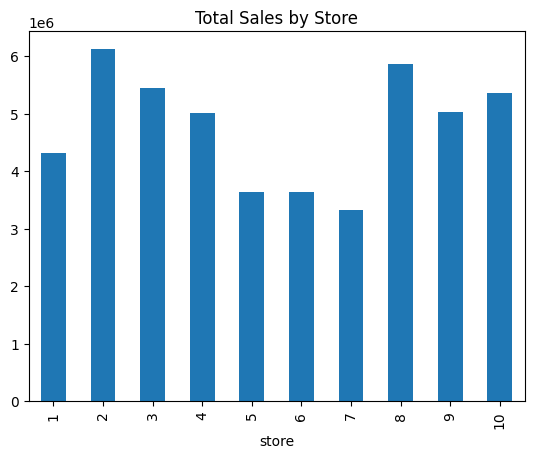

In [10]:
print(Q1 , Q3 , IQR , lower_bound , upper_bound )

store_sales = df.groupby("store")["sales"].sum()

plt.figure()
store_sales.plot(kind="bar")
plt.title("Total Sales by Store")
plt.show()

In [11]:
# -------------------------------------------------
# Sort Data (MANDATORY before lag/rolling)
# -------------------------------------------------

df = df.sort_values(["store", "item", "date"])

In [12]:
# -------------------------------------------------
# Log Transform (Recommended)
# -------------------------------------------------

df["sales_log"] = np.log1p(df["sales"])

In [13]:
# -------------------------------------------------
# Cyclical Encoding
# -------------------------------------------------

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [14]:
# -------------------------------------------------
# Lag Features (Balanced Strategy)
# -------------------------------------------------

lags = [7, 30, 90]

for lag in lags:
    df[f"lag_{lag}"] = (
        df
        .groupby(["store", "item"])["sales_log"]
        .shift(lag)
    )


# -------------------------------------------------
# Rolling Window Features
# -------------------------------------------------

windows = [7]

for window in windows:

    df[f"rolling_mean_{window}"] = (
        df
        .groupby(["store", "item"])["sales_log"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    df[f"rolling_std_{window}"] = (
        df
        .groupby(["store", "item"])["sales_log"]
        .shift(1)
        .rolling(window=window)
        .std()
    )



In [15]:
# -------------------------------------------------
# Calendar Flags (Useful for Retail)
# -------------------------------------------------

df["is_month_start"] = (
    df["date"]
    .dt.is_month_start
    .astype(int)
)

df["is_month_end"] = (
    df["date"]
    .dt.is_month_end
    .astype(int)
)

In [16]:
# -------------------------------------------------
# Drop Only Critical NaNs
# (prevents unnecessary data loss)
# -------------------------------------------------

df_final = df.dropna(subset=[
    "lag_7",
    "lag_30",
    "lag_90",
    "rolling_mean_7"
]).copy()

In [17]:
# -------------------------------------------------
# 10. Check Final Dataset
# -------------------------------------------------

print("Final shape:", df_final.shape)

print("\nMissing values:")
print(df_final.isna().sum().sum())


Final shape: (868000, 23)

Missing values:
0


In [18]:
df_final

,date,store,item,sales,year,month,day,day_of_week,is_weekend,quarter,...,month_cos,dow_sin,dow_cos,lag_7,lag_30,lag_90,rolling_mean_7,rolling_std_7,is_month_start,is_month_end
90,2013-04-01,1,1,11,2013,4,1,0,0,2,...,-0.5,0.000000,1.000000,2.639057,2.639057,2.639057,2.789552,0.207243,1,0
91,2013-04-02,1,1,19,2013,4,2,1,0,2,...,-0.5,0.781831,0.623490,2.833213,3.044522,2.484907,2.767530,0.232545,0,0
92,2013-04-03,1,1,24,2013,4,3,2,0,2,...,-0.5,0.974928,-0.222521,2.484907,2.708050,2.708050,2.790747,0.247808,0,0
93,2013-04-04,1,1,18,2013,4,4,3,0,2,...,-0.5,0.433884,-0.900969,2.639057,2.639057,2.639057,2.895600,0.252074,0,0
94,2013-04-05,1,1,19,2013,4,5,4,0,2,...,-0.5,-0.433884,-0.900969,2.890372,2.890372,2.397895,2.939226,0.225277,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2017,12,27,2,0,4,...,1.0,0.974928,-0.222521,3.951244,4.330733,4.418841,4.105180,0.230204,0,0
912996,2017-12-28,10,50,59,2017,12,28,3,0,4,...,1.0,0.433884,-0.900969,4.158883,4.234107,4.510860,4.134843,0.220224,0,0
912997,2017-12-29,10,50,74,2017,12,29,4,0,4,...,1.0,-0.433884,-0.900969,4.330733,4.343805,4.644391,4.125623,0.220401,0,0
912998,2017-12-30,10,50,62,2017,12,30,5,1,4,...,1.0,-0.974928,-0.222521,4.262680,4.304065,4.605170,4.123731,0.218394,0,0


In [19]:
df_final.columns

Index(['date', 'store', 'item', 'sales', 'year', 'month', 'day', 'day_of_week',
       'is_weekend', 'quarter', 'time_index', 'sales_log', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos', 'lag_7', 'lag_30', 'lag_90',
       'rolling_mean_7', 'rolling_std_7', 'is_month_start', 'is_month_end'],
      dtype='str')

In [20]:
# -------------------------------------------------
#  Save Processed Dataset
# -------------------------------------------------
df_final.to_csv("data/processed_inventory_demand.csv", index=False) 